# EDA of AsmonTV Comments

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

## Initial Impressions

In [23]:
df = pd.read_json('../../data/raw/AsmonTV_batch_20260608_205250.json')
df.head()

,video_id,text,likes,published_at
0,hOZd3wF0i7I,"""They targeted me because of my race!""\n\n*Bla...",746,2026-06-08 19:06:39+00:00
1,hOZd3wF0i7I,this lady was a dlc character for concord 🤣,776,2026-06-08 19:14:09+00:00
2,hOZd3wF0i7I,"""They axed me""\n\nThe fatigue man",246,2026-06-08 20:27:18+00:00
3,hOZd3wF0i7I,Noticing Patterns fatigue,1802,2026-06-08 18:01:40+00:00
4,hOZd3wF0i7I,"""When you get used to preferential treatment, ...",1209,2026-06-08 18:17:17+00:00


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49997 entries, 0 to 49996
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   video_id      49997 non-null  str                
 1   text          49997 non-null  str                
 2   likes         49997 non-null  int64              
 3   published_at  49997 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), int64(1), str(2)
memory usage: 1.5 MB


## Comment Length Analysis

In [ ]:
df["word_count"] = (
    df["text"]
    .fillna("")
    .str.split()
    .str.len()
)
df["word_count"].describe(percentiles=[.5,.75,.9,.95,.99,0.999])

count    49997.000000
mean        16.514091
std         19.677525
min          1.000000
25%          8.000000
50%         12.000000
75%         19.000000
max       1524.000000
Name: word_count, dtype: float64

,video_id,text,likes,published_at,word_count
0,hOZd3wF0i7I,"""They targeted me because of my race!""\n\n*Bla...",746,2026-06-08 19:06:39+00:00,13
1,hOZd3wF0i7I,this lady was a dlc character for concord 🤣,776,2026-06-08 19:14:09+00:00,9
2,hOZd3wF0i7I,"""They axed me""\n\nThe fatigue man",246,2026-06-08 20:27:18+00:00,6
3,hOZd3wF0i7I,Noticing Patterns fatigue,1802,2026-06-08 18:01:40+00:00,3
4,hOZd3wF0i7I,"""When you get used to preferential treatment, ...",1209,2026-06-08 18:17:17+00:00,13


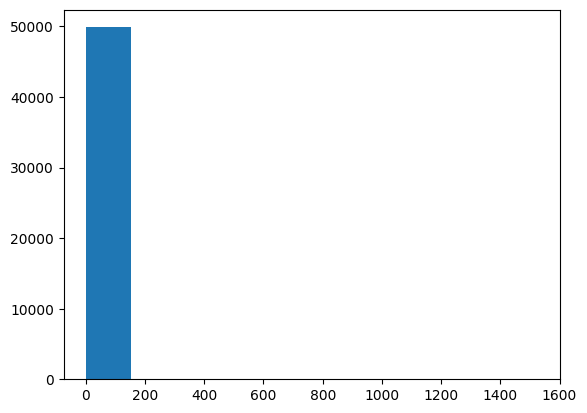

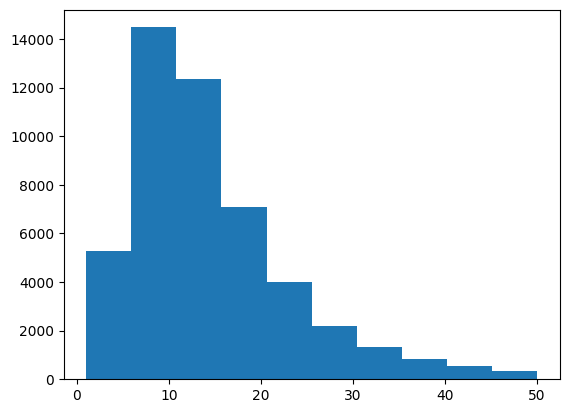

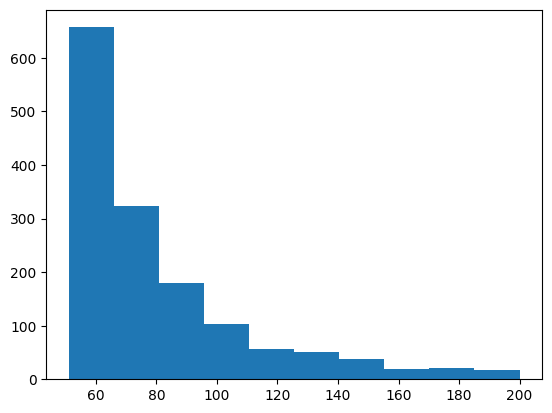

In [27]:
plt.figure()
plt.hist(df['word_count'])

plt.figure()
plt.hist(df.loc[df['word_count']<= 50, 'word_count'])

plt.figure()
plt.hist(df.loc[(df['word_count']> 50) & (df['word_count'] <= 200), 'word_count'])
plt.show()

## Individual Word Analysis
Used a basic tokenizer, matches strings of uninterupted alphanumeric characters

In [28]:
import re

def tokenize(text):
    text = text.lower()
    return re.findall(r"\b[a-z0-9]+\b", text)

df['tokens'] = df['text'].apply(tokenize)

In [29]:
df[['text','tokens']].head()

,text,tokens
0,"""They targeted me because of my race!""\n\n*Bla...","[they, targeted, me, because, of, my, race, bl..."
1,this lady was a dlc character for concord 🤣,"[this, lady, was, a, dlc, character, for, conc..."
2,"""They axed me""\n\nThe fatigue man","[they, axed, me, the, fatigue, man]"
3,Noticing Patterns fatigue,"[noticing, patterns, fatigue]"
4,"""When you get used to preferential treatment, ...","[when, you, get, used, to, preferential, treat..."


Approximately 30,000 unique 'words'. The most common do seem to be just basic english words. Will probably want to use a stop words list to filter these. I've looked and there seems to be plenty of premade lists available.

In [30]:
from collections import Counter

counter = Counter()
for tokens in df['tokens']:
    counter.update(tokens)
print("Unique words: ", len(counter))
counter.most_common(10)

Unique words:  30117


[('the', 35700),
 ('a', 20216),
 ('to', 19940),
 ('is', 15043),
 ('and', 14800),
 ('i', 14729),
 ('of', 12862),
 ('it', 11497),
 ('that', 10741),
 ('in', 10462)]

Of the ~30,000 words, approximately half appear only once in all comments. Some seem to be random character strings (eg. huuhuuhuu), but most do appear to just be uncommon words.

In [42]:
import random
singletons = {
    word
    for word, count in counter.items()
    if count == 1
}

print('Number of singletons: ',len(singletons))
print('Percentage of total words: ',len(singletons) / len(counter))
print('Examples:')
random.seed(2)
random.sample(list(singletons), 10)

Number of singletons:  13027
Percentage of total words:  0.4325464023641133
Examples:


['ez',
 'whoevers',
 'sweetness',
 'outsded',
 'follicle',
 'musashi',
 'carved',
 'hanji',
 'huuhuuhuu',
 '30fps']

Because of the simple tokenization method we end up with many artifact words like 'don' and 't' (coming from 'don't'). Will need to think harder about how we deal with these.

In [31]:
artifact_words = {
    "don",
    "doesn",
    "didn",
    "isn",
    "aren",
    "wasn",
    "weren",
    "won",
    "wouldn",
    "couldn",
    "shouldn",
    "ve",
    "ll",
    "re",
    "nt",
    "m"
}

artifact_df = pd.DataFrame(
    [
        (word, counter[word])
        for word in artifact_words
    ],
    columns=["token", "frequency"]
)

artifact_df = artifact_df.sort_values(
    "frequency",
    ascending=False
).reset_index(drop=True)

display(artifact_df)

,token,frequency
0,m,1999
1,don,1986
2,re,1770
3,ve,1068
4,didn,963
5,doesn,686
6,ll,566
7,isn,539
8,wasn,355
9,won,323


## Time Span Analysis

In [33]:
print('Earliest date: ',df['published_at'].min())
print('Latest date: ',df['published_at'].max())
print('Time span: ', df['published_at'].max()-df['published_at'].min())

Earliest date:  2026-01-25 13:32:44+00:00
Latest date:  2026-06-09 00:46:23+00:00
Time span:  134 days 11:13:39


Daily comment numbers seem somewhat consistent. There are big lags, although this would make sense with video post dates. Approx. 350-400 comments per day.

Daily Comment Statistics
Mean:     367.62
Median:   392.50
Min:      8
Max:      708
Std Dev:  138.23


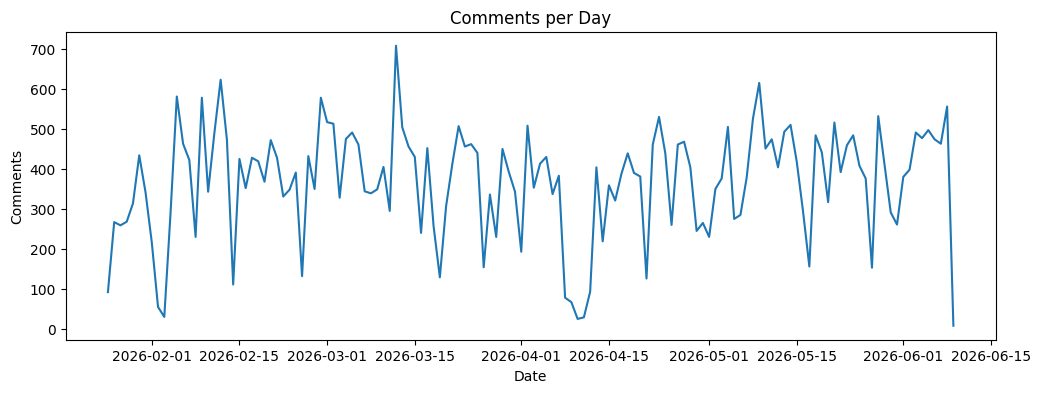

In [44]:
daily_counts = (
    df.groupby(df["published_at"].dt.date)
      .size()
)

print("Daily Comment Statistics")
print(f"Mean:     {daily_counts.mean():.2f}")
print(f"Median:   {daily_counts.median():.2f}")
print(f"Min:      {daily_counts.min()}")
print(f"Max:      {daily_counts.max()}")
print(f"Std Dev:  {daily_counts.std():.2f}")

plt.figure(figsize=(12, 4))
daily_counts.plot()

plt.title("Comments per Day")
plt.ylabel("Comments")
plt.xlabel("Date")

plt.show()

C:\Users\alexv\AppData\Local\Temp\ipykernel_39536\1121114334.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.groupby(df["published_at"].dt.to_period("W"))


Weekly Comment Statistics
Mean:     2380.81
Median:   2633.00
Min:      92
Max:      3180
Std Dev:  841.07


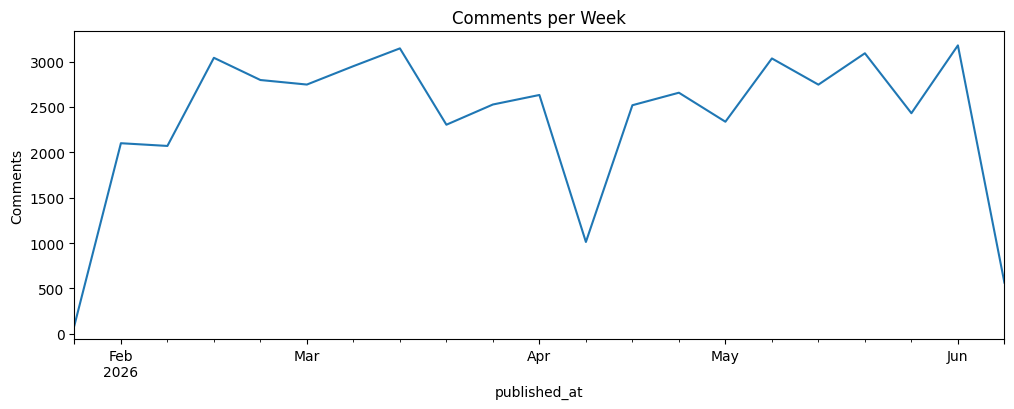

In [45]:
weekly_counts = (
    df.groupby(df["published_at"].dt.to_period("W"))
      .size()
)

print("Weekly Comment Statistics")
print(f"Mean:     {weekly_counts.mean():.2f}")
print(f"Median:   {weekly_counts.median():.2f}")
print(f"Min:      {weekly_counts.min()}")
print(f"Max:      {weekly_counts.max()}")
print(f"Std Dev:  {weekly_counts.std():.2f}")


weekly_counts.plot(figsize=(12,4))
plt.title("Comments per Week")
plt.ylabel("Comments")
plt.show()